In [3]:
from pathlib import Path
import sys

import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image


In [4]:
PROJECT_ROOT = Path().cwd().parent
sys.path.append(str(PROJECT_ROOT))
sys.path


['/opt/homebrew/Cellar/python@3.14/3.14.3_1/Frameworks/Python.framework/Versions/3.14/lib/python314.zip',
 '/opt/homebrew/Cellar/python@3.14/3.14.3_1/Frameworks/Python.framework/Versions/3.14/lib/python3.14',
 '/opt/homebrew/Cellar/python@3.14/3.14.3_1/Frameworks/Python.framework/Versions/3.14/lib/python3.14/lib-dynload',
 '',
 '/Users/vinaykumarmandalapu/Desktop/VisionInspect_AI/backend/myvenv/lib/python3.14/site-packages',
 '/Users/vinaykumarmandalapu/Desktop/VisionInspect_AI']

In [5]:
from ai.dataset.mvtec_loader import MVTecLoader


In [6]:
DATASET_ROOT = PROJECT_ROOT / "mvtec_anomaly_detection"
loader = MVTecLoader(dataset_root=DATASET_ROOT)
loader


In [7]:
categories = loader.get_categories()
print("Number of categories:", len(categories))
print("Categories:", categories)


Number of categories: 15
Categories: ['bottle', 'cable', 'capsule', 'carpet', 'grid', 'hazelnut', 'leather', 'metal_nut', 'pill', 'screw', 'tile', 'toothbrush', 'transistor', 'wood', 'zipper']


In [8]:
all_records = []
for category in categories:
    records = loader.load_category(category)
    all_records.extend(records)
df = pd.DataFrame(all_records)


In [10]:
display(len(df))
print(df.tail(5))

5354

     category split    defect_type  \
5349   zipper  test  fabric_border   
5350   zipper  test  fabric_border   
5351   zipper  test  fabric_border   
5352   zipper  test  fabric_border   
5353   zipper  test  fabric_border   

                                             image_path  \
5349  /Users/vinaykumarmandalapu/Desktop/VisionInspe...   
5350  /Users/vinaykumarmandalapu/Desktop/VisionInspe...   
5351  /Users/vinaykumarmandalapu/Desktop/VisionInspe...   
5352  /Users/vinaykumarmandalapu/Desktop/VisionInspe...   
5353  /Users/vinaykumarmandalapu/Desktop/VisionInspe...   

                                              mask_path  
5349  /Users/vinaykumarmandalapu/Desktop/VisionInspe...  
5350  /Users/vinaykumarmandalapu/Desktop/VisionInspe...  
5351  /Users/vinaykumarmandalapu/Desktop/VisionInspe...  
5352  /Users/vinaykumarmandalapu/Desktop/VisionInspe...  
5353  /Users/vinaykumarmandalapu/Desktop/VisionInspe...  


In [ ]:
df.size


26770

In [23]:
df.groupby(["category", "split"]).size()


category    split
bottle      test      83
            train    209
cable       test     150
            train    224
capsule     test     132
            train    219
carpet      test     117
            train    280
grid        test      78
            train    264
hazelnut    test     110
            train    391
leather     test     124
            train    245
metal_nut   test     115
            train    220
pill        test     167
            train    267
screw       test     160
            train    320
tile        test     117
            train    230
toothbrush  test      42
            train     60
transistor  test     100
            train    213
wood        test      79
            train    247
zipper      test     151
            train    240
dtype: int64

In [24]:
df.groupby(["category", "defect_type"]).size()


category  defect_type    
bottle    broken_large        20
          broken_small        22
          contamination       21
          good               229
cable     bent_wire           13
                            ... 
zipper    fabric_interior     16
          good               272
          rough               17
          split_teeth         18
          squeezed_teeth      16
Length: 88, dtype: int64

In [25]:
df["split"].value_counts()


split
train    3629
test     1725
Name: count, dtype: int64

In [26]:
print("Total records:", len(df))
print("\nSplit distribution:")
print(df["split"].value_counts())

print("\nRecords per category:")
print(df["category"].value_counts())


Total records: 5354

Split distribution:
split
train    3629
test     1725
Name: count, dtype: int64

Records per category:
category
hazelnut      501
screw         480
pill          434
carpet        397
zipper        391
cable         374
leather       369
capsule       351
tile          347
grid          342
metal_nut     335
wood          326
transistor    313
bottle        292
toothbrush    102
Name: count, dtype: int64


In [28]:
print("Defect counts")
df["defect_type"].value_counts()


Defect counts


defect_type
good                    4096
color                     93
scratch                   91
crack                     84
combined                  55
cut                       53
hole                      45
contamination             42
faulty_imprint            41
poke                      39
bent                      37
rough                     32
thread                    30
glue                      30
defective                 30
metal_contamination       28
scratch_neck              25
manipulated_front         24
scratch_head              24
flip                      23
thread_top                23
thread_side               23
broken_small              22
broken_large              20
squeeze                   20
broken_teeth              19
glue_strip                18
oil                       18
split_teeth               18
print                     17
fold                      17
fabric_border             17
gray_stroke               16
fabric_interior           16
sq

In [29]:
print("\nCategory × split:")
print(
    df.groupby(["category", "split"])
      .size()
      .unstack(fill_value=0)
)



Category × split:
split       test  train
category               
bottle        83    209
cable        150    224
capsule      132    219
carpet       117    280
grid          78    264
hazelnut     110    391
leather      124    245
metal_nut    115    220
pill         167    267
screw        160    320
tile         117    230
toothbrush    42     60
transistor   100    213
wood          79    247
zipper       151    240


In [30]:
print("\nCategory × defect type:")
print(
    df.groupby(["category", "defect_type"])
      .size()
      .unstack(fill_value=0)
)



Category × defect type:
defect_type  bent  bent_lead  bent_wire  broken  broken_large  broken_small  \
category                                                                      
bottle          0          0          0       0            20            22   
cable           0          0         13       0             0             0   
capsule         0          0          0       0             0             0   
carpet          0          0          0       0             0             0   
grid           12          0          0      12             0             0   
hazelnut        0          0          0       0             0             0   
leather         0          0          0       0             0             0   
metal_nut      25          0          0       0             0             0   
pill            0          0          0       0             0             0   
screw           0          0          0       0             0             0   
tile            0          

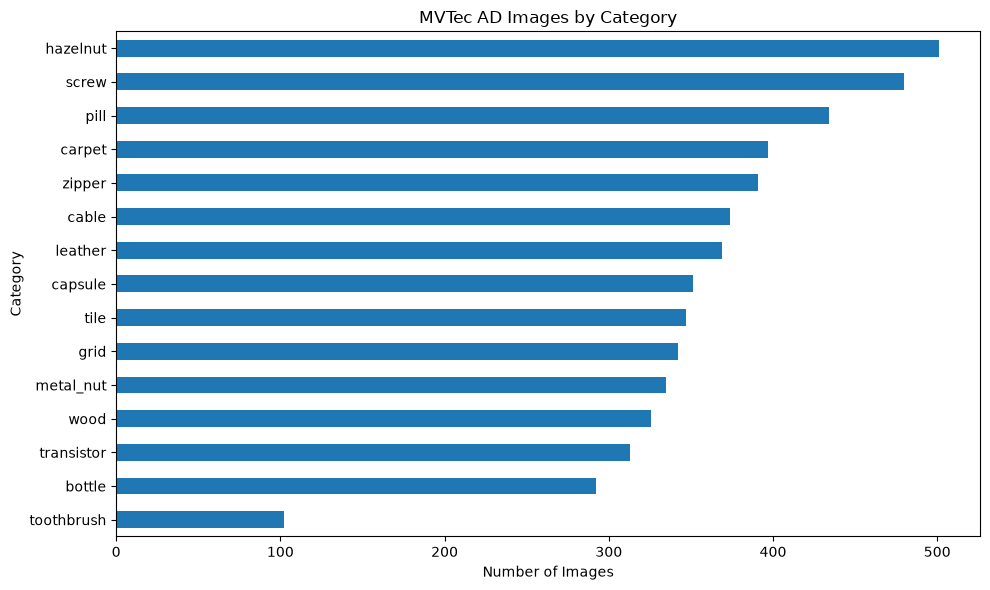

In [31]:
category_counts = df["category"].value_counts().sort_values()

plt.figure(figsize=(10, 6))
category_counts.plot(kind="barh")

plt.title("MVTec AD Images by Category")
plt.xlabel("Number of Images")
plt.ylabel("Category")
plt.tight_layout()
plt.show()


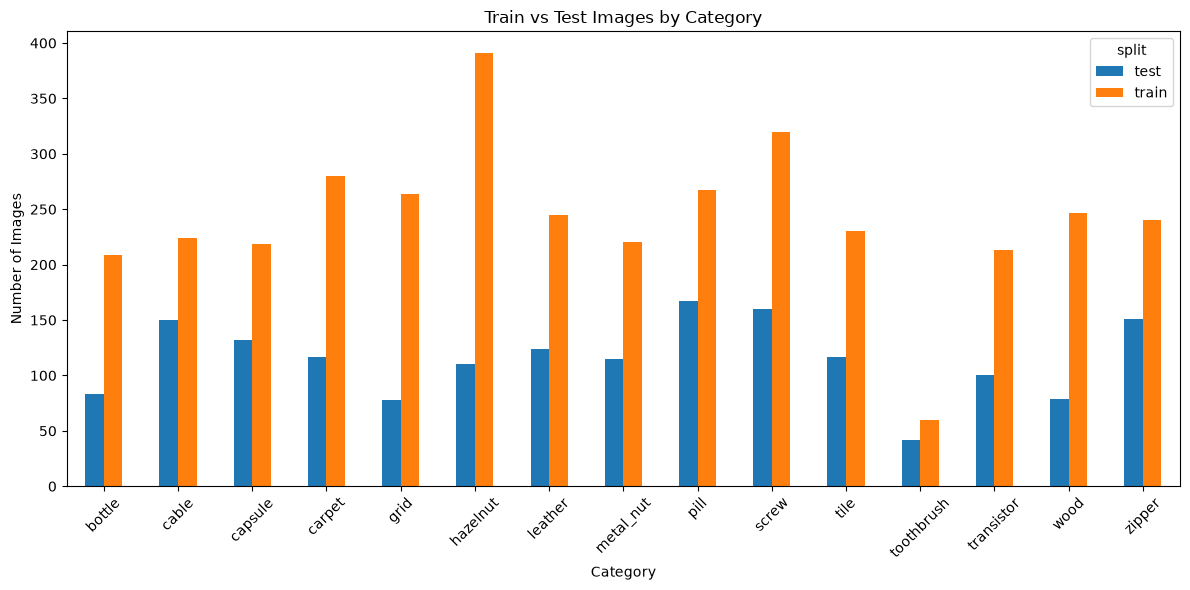

In [32]:
split_counts = (
    df.groupby(["category", "split"])
      .size()
      .unstack(fill_value=0)
)

split_counts.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Train vs Test Images by Category")
plt.xlabel("Category")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [33]:
df["label"] = df["defect_type"].apply(
    lambda x: "Good" if x == "good" else "Defective"
)


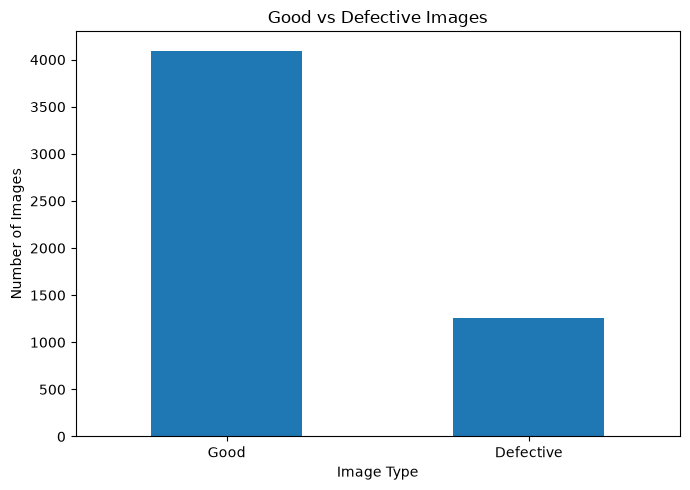

In [34]:
label_counts = df["label"].value_counts()

plt.figure(figsize=(7, 5))
label_counts.plot(kind="bar")

plt.title("Good vs Defective Images")
plt.xlabel("Image Type")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [35]:
label_percentages = (
    df["label"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(label_percentages)


label
Good         76.5
Defective    23.5
Name: proportion, dtype: float64


In [36]:
sample_dimensions = []

for path in df["image_path"].sample(200, random_state=42):
    with Image.open(path) as img:
        sample_dimensions.append(img.size)

dimension_counts = pd.Series(sample_dimensions).value_counts()

print(dimension_counts.head(10))


(1024, 1024)    127
(800, 800)       20
(700, 700)       15
(900, 900)       14
(840, 840)       13
(1000, 1000)     11
Name: count, dtype: int64


## EDA Conclusions

- The MVTec AD dataset contains 5,354 images across 15 categories.
- The dataset contains 3,629 training images and 1,725 test images.
- The dataset contains 4,096 good images and 1,258 defective images.
- The number of images varies significantly between categories.
- Defect types are category-specific rather than a single universal set of defect classes.
- Ground-truth masks are available for defective test images.
- A sample of 200 images showed multiple image resolutions, with 1024×1024 being the most frequent.
- Therefore, image preprocessing will be required before model inference/training to provide a consistent input size.
